
# Projet Data Science : Ames Housing (House Prices)

**Méthodologie :** CRISP-ML(Q)

Ce notebook retrace l'intégralité de notre pipeline d'apprentissage automatique pour prédire le prix des maisons à Ames, de l'exploration initiale des données jusqu'au déploiement (soumission Kaggle).

In [35]:
# Importation des librairies standards
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from scipy.stats import skew, norm
from scipy.special import boxcox1p

# Librairies de Machine Learning
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LassoCV
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV, cross_val_score, cross_val_predict
from sklearn.metrics import mean_squared_error
import category_encoders as ce

# Configuration
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="muted")

## Phase 1 : Business & Data Understanding (Analyse Exploratoire)
Avant de nettoyer ou de modéliser, nous devons comprendre le problème métier et la structure de nos données.
1. **La variable cible (SalePrice) :** Quelle est sa distribution ?
2. **Les valeurs aberrantes :** Y a-t-il des transactions anormales qui pourraient fausser notre modèle ?
3. **Corrélations :** Quelles sont les variables qui semblent le plus influencer le prix ?

Dimensions du jeu d'entraînement : (1460, 81)


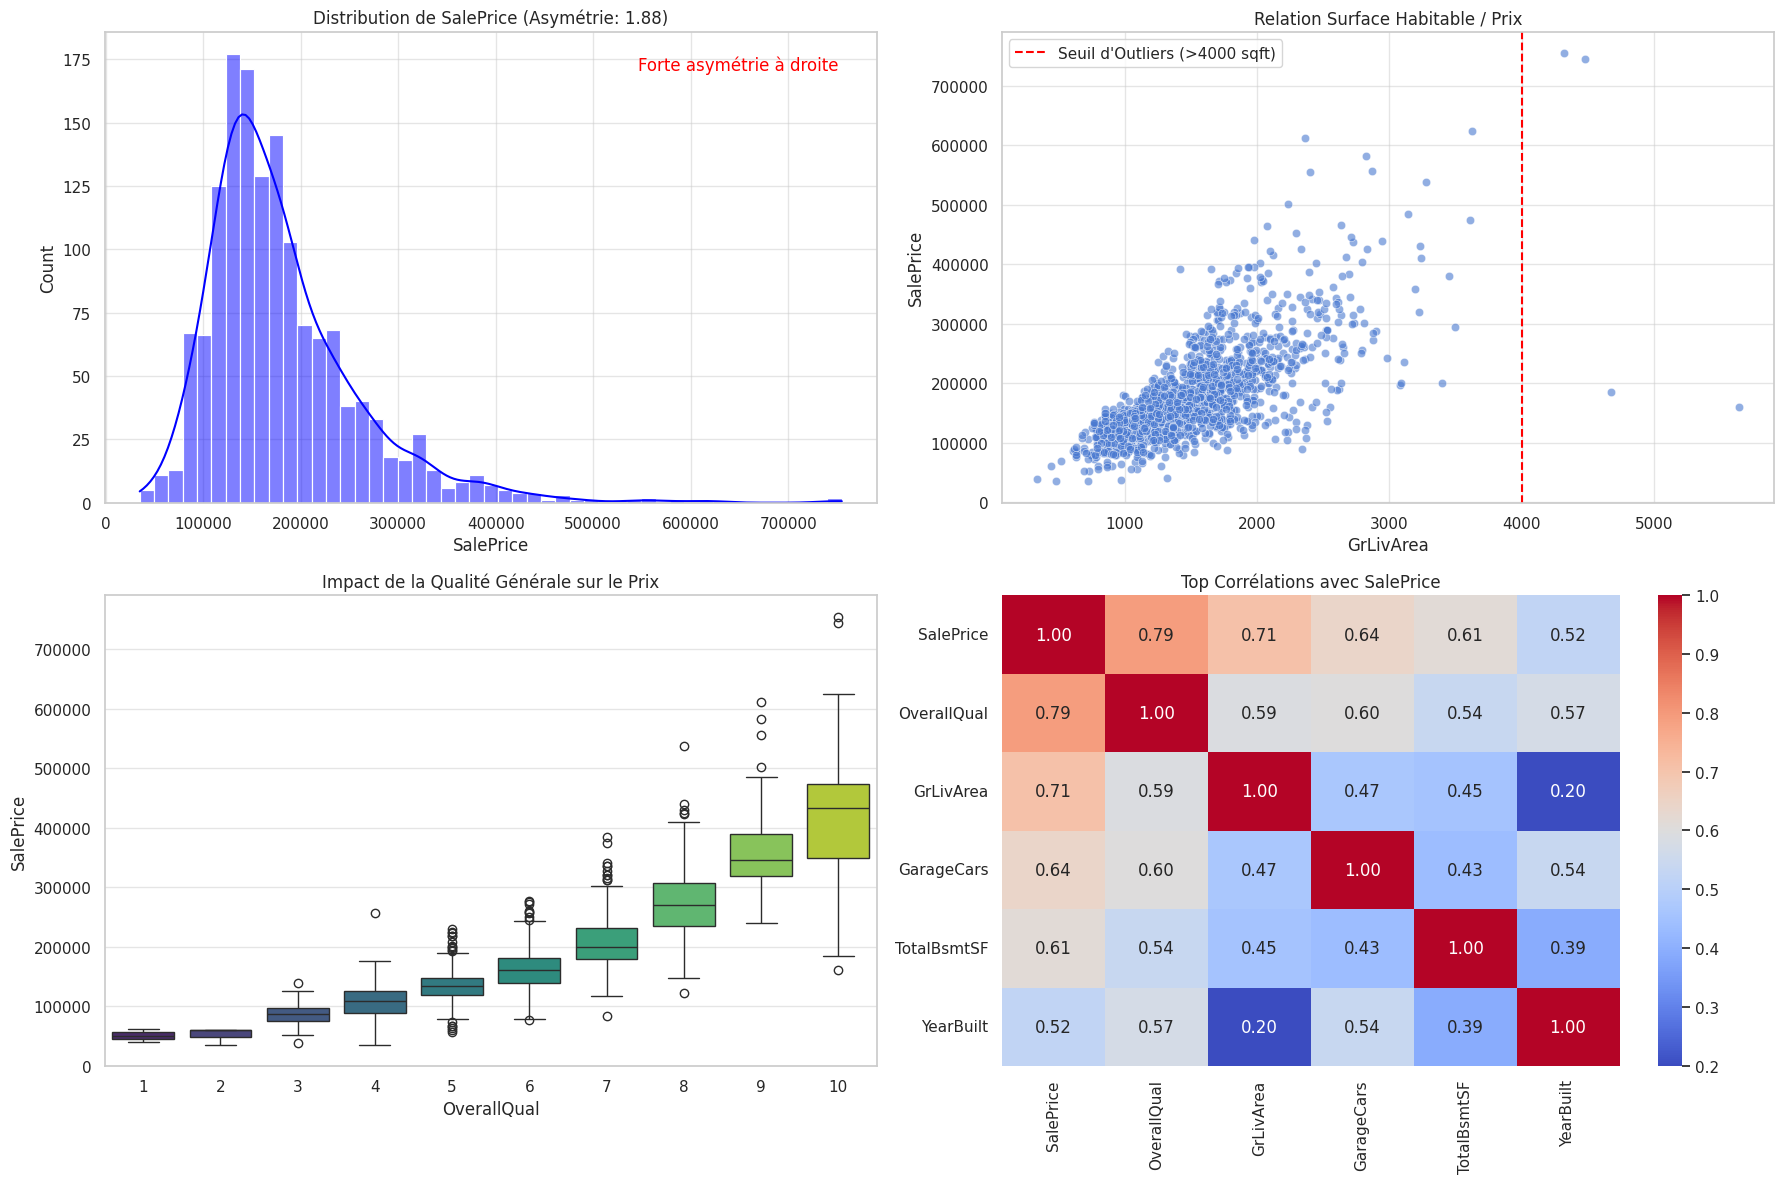

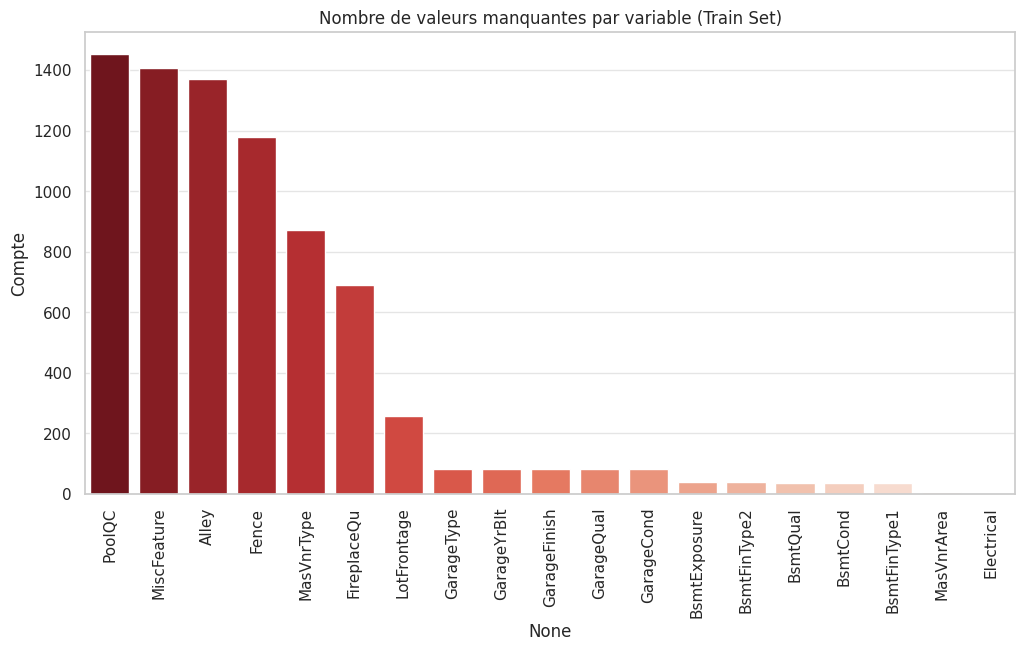

In [36]:
# Chargement initial pour l'exploration
train_raw = pd.read_csv('Data/train.csv')
test_raw = pd.read_csv('Data/test.csv')

print(f"Dimensions du jeu d'entraînement : {train_raw.shape}")

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# 1. Distribution de la variable cible
skewness = train_raw['SalePrice'].skew()
sns.histplot(train_raw['SalePrice'], kde=True, ax=axes[0, 0], color='blue')
axes[0, 0].set_title(f'Distribution de SalePrice (Asymétrie: {skewness:.2f})')
axes[0, 0].text(x=0.95, y=0.95, s="Forte asymétrie à droite", transform=axes[0, 0].transAxes,
                ha='right', va='top', fontsize=12, color='red')


# 2. Identification des Outliers (Surface vs Prix)
sns.scatterplot(data=train_raw, x='GrLivArea', y='SalePrice', ax=axes[0, 1], alpha=0.6)
axes[0, 1].axvline(x=4000, color='red', linestyle='--', label='Seuil d\'Outliers (>4000 sqft)')
axes[0, 1].set_title('Relation Surface Habitable / Prix')
axes[0, 1].legend()

# 3. Qualité vs Prix (Variable catégorielle)
sns.boxplot(data=train_raw, x='OverallQual', y='SalePrice', ax=axes[1, 0], palette='viridis')
axes[1, 0].set_title('Impact de la Qualité Générale sur le Prix')

# 4. Matrice de corrélation des top variables numériques
top_features = ['SalePrice', 'OverallQual', 'GrLivArea', 'GarageCars', 'TotalBsmtSF', 'YearBuilt']
corr_matrix = train_raw[top_features].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", ax=axes[1, 1])
axes[1, 1].set_title('Top Corrélations avec SalePrice')

plt.tight_layout()
plt.show()

# 5. Visualisation des valeurs manquantes
plt.figure(figsize=(12, 6))
missing_data = train_raw.isnull().sum()
missing_data = missing_data[missing_data > 0].sort_values(ascending=False)
sns.barplot(x=missing_data.index, y=missing_data.values, palette='Reds_r')
plt.xticks(rotation=90)
plt.title('Nombre de valeurs manquantes par variable (Train Set)')
plt.ylabel('Compte')
plt.show()


**Conclusions de la Phase 1 :**
* **Le problème n°1 est mathématiquement confirmé :** La cible `SalePrice` n'est pas normale. Son coefficient d'asymétrie (skewness) est de **1.88**, ce qui indique une forte asymétrie vers la droite. De nombreux modèles de régression fonctionnent mal avec une cible aussi déformée.
* **Action immédiate :** Nous allons appliquer une transformation logarithmique (`np.log1p`) à `SalePrice`. Cela va normaliser sa distribution, stabiliser la variance et aider le modèle à apprendre plus efficacement.
* **Aberrations vs Maisons de luxe :** Il y a quelques aberrations évidentes (très grande surface pour un prix très bas) à supprimer. Cependant, pour les maisons légitimement chères, nous devons aider le modèle à comprendre *pourquoi* elles le sont via du feature engineering.
* **Importance des variables :** La qualité (`OverallQual`) et la surface (`GrLivArea`) sont les deux variables les plus corrélées au prix. Leur interaction sera probablement très informative.
* **Stratégie pour les NAs :** Beaucoup de "NAs" ne sont pas des erreurs mais signifient "Absence de l'équipement" (ex: `PoolQC`). Notre stratégie de remplissage doit en tenir compte.

## Phase 2 : Data Engineering (Préparation des données)
Sur la base de notre exploration, nous allons nettoyer le dataset, transformer la cible et créer des variables stratégiques.

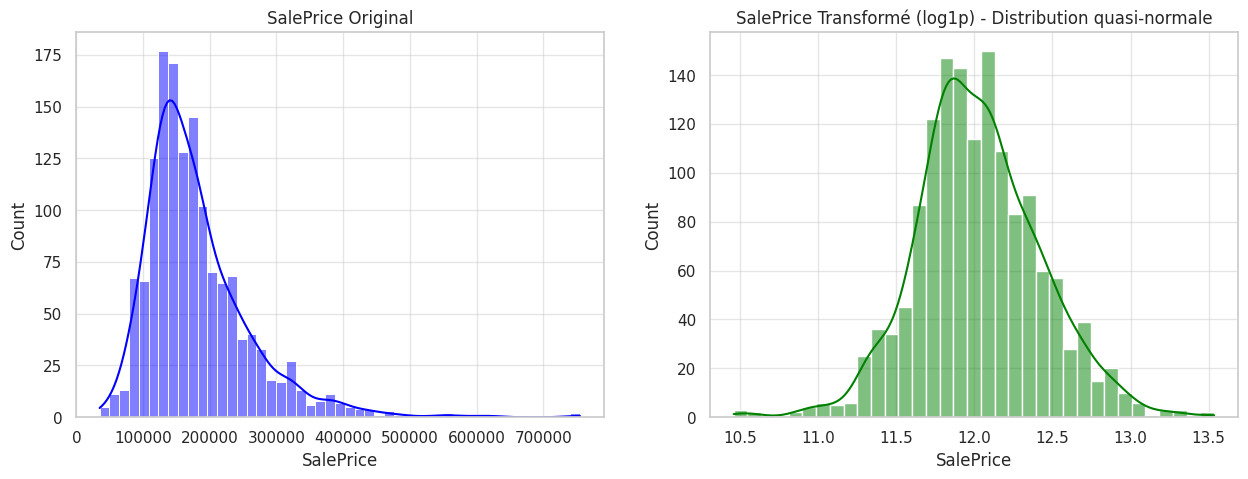

In [37]:
# 1. Traitement des Outliers identifiés en Phase 1
train_clean = train_raw.copy()
# Suppression des valeurs aberrantes évidentes (Plus sûre : Surface très grande mais prix très bas)
train_clean = train_clean.drop(train_clean[(train_clean['GrLivArea']>4000) & (train_clean['SalePrice']<300000)].index)

# 2. Transformation de la variable cible et CORRECTION DE L'INDEX
y_train = np.log1p(train_clean['SalePrice']).reset_index(drop=True)

# Visualisation de la transformation de la cible
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(train_clean['SalePrice'], kde=True, ax=axes[0], color='blue')
axes[0].set_title('SalePrice Original')
sns.histplot(y_train, kde=True, ax=axes[1], color='green')
axes[1].set_title('SalePrice Transformé (log1p) - Distribution quasi-normale')
plt.show()

train_clean.drop(['SalePrice', 'Id'], axis=1, inplace=True)

test_ids = test_raw['Id']
test_clean = test_raw.drop(['Id'], axis=1).copy()

# Concaténation pour traiter les NAs et encoder uniformément
ntrain = train_clean.shape[0]
all_data = pd.concat([train_clean, test_clean], axis=0).reset_index(drop=True)

# Suppression des variables à faible variance (inutiles)
all_data.drop(['Utilities'], axis=1, inplace=True)

# 3. Gestion experte des valeurs manquantes (NAs)
cols_none = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
             'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
             'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'MasVnrType']
for col in cols_none:
    all_data[col] = all_data[col].fillna('None')

cols_zero = ['GarageArea', 'GarageCars', 'BsmtFinSF1',
             'BsmtFinSF2', 'BsmtUnfSF','TotalBsmtSF', 'BsmtFullBath', 'BsmtHalfBath', 'MasVnrArea']
for col in cols_zero:
    all_data[col] = all_data[col].fillna(0)

# Imputation spécifique pour l'année du garage
all_data['GarageYrBlt'] = all_data['GarageYrBlt'].fillna(all_data['YearBuilt'])

# LotFrontage : Imputation astucieuse par la médiane du quartier
all_data["LotFrontage"] = all_data.groupby("Neighborhood")["LotFrontage"].transform(lambda x: x.fillna(x.median()))

# Reste des NAs : Médiane (numériques) et Mode (catégorielles)
num_cols = all_data.select_dtypes(exclude=['object']).columns
all_data[num_cols] = all_data[num_cols].fillna(all_data[num_cols].median())

cat_cols = all_data.select_dtypes(include=['object']).columns
for col in cat_cols:
    all_data[col] = all_data[col].fillna(all_data[col].mode()[0])

# 4. Feature Engineering Stratégique
# 4.1 Création de variables d'âge
all_data['Age_At_Sale'] = all_data['YrSold'] - all_data['YearBuilt']
all_data['Years_Since_Remodel'] = all_data['YrSold'] - all_data['YearRemodAdd']

# 4.2 Encodage Ordinal des variables de qualité
qual_map = {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'None': 0}
qual_cols = ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'HeatingQC', 'KitchenQual', 'FireplaceQu', 'GarageQual', 'GarageCond', 'PoolQC']
for col in qual_cols:
    all_data[col] = all_data[col].map(qual_map).astype(int)

# 4.3 Création de variables d'interaction et de "luxe"
all_data['Qual_x_Area'] = all_data['OverallQual'] * all_data['GrLivArea']
all_data['Is_Luxury_Neighborhood'] = all_data['Neighborhood'].isin(['NoRidge', 'NridgHt', 'StoneBr']).astype(int)

# 4.4 Création de variables générales
all_data['TotalSF'] = all_data['TotalBsmtSF'] + all_data['1stFlrSF'] + all_data['2ndFlrSF']
all_data['Total_Bathrooms'] = (all_data['FullBath'] + (0.5 * all_data['HalfBath']) +
                               all_data['BsmtFullBath'] + (0.5 * all_data['BsmtHalfBath']))
all_data['Total_porch_sf'] = (all_data['OpenPorchSF'] + all_data['3SsnPorch'] +
                              all_data['EnclosedPorch'] + all_data['ScreenPorch'] +
                              all_data['WoodDeckSF'])
all_data['HasBsmt'] = all_data['TotalBsmtSF'].apply(lambda x: 1 if x > 0 else 0)
all_data['HasGarage'] = all_data['GarageArea'].apply(lambda x: 1 if x > 0 else 0)
all_data['HasPool'] = all_data['PoolArea'].apply(lambda x: 1 if x > 0 else 0)
all_data['HasFireplace'] = all_data['Fireplaces'].apply(lambda x: 1 if x > 0 else 0)

# 4.5 Transformation de variables numériques qui sont sémantiquement des catégories
all_data['MSSubClass'] = all_data['MSSubClass'].astype(str)
all_data['MoSold'] = all_data['MoSold'].astype(str)
all_data['YrSold'] = all_data['YrSold'].astype(str)

# 5. Réduction de l'asymétrie (Skewness) sur les variables numériques
numeric_feats = all_data.dtypes[all_data.dtypes != "object"].index
skewed_feats = all_data[numeric_feats].apply(lambda x: skew(x.dropna())).sort_values(ascending=False)
skewness = pd.DataFrame({'Skew' :skewed_feats})
skewness = skewness[abs(skewness.Skew) > 0.75] # Filtre sur asymétrie forte
skewed_features = skewness.index
lam = 0.15
for feat in skewed_features:
    all_data[feat] = boxcox1p(all_data[feat], lam)

# Reséparation
X_train = all_data.iloc[:ntrain].copy()
X_test = all_data.iloc[ntrain:].copy()

# 6. Target Encoding Avancé avec Category Encoders (Évite l'overfitting avec smoothing)
target_cols = ['Neighborhood', 'MSSubClass', 'Exterior1st', 'Exterior2nd']
target_encoder = ce.TargetEncoder(cols=target_cols, smoothing=10)
X_train[target_cols] = target_encoder.fit_transform(X_train[target_cols], y_train)
X_test[target_cols] = target_encoder.transform(X_test[target_cols])

# 7. One-Hot Encoding pour le reste
X_train = pd.get_dummies(X_train)
X_test = pd.get_dummies(X_test)

# Alignement pour s'assurer que train et test ont exactement les mêmes colonnes
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

## Phase 3 : Feature Selection (Modélisation Avancée)
Nous avons généré de nombreuses colonnes. Pour éviter la malédiction de la dimensionnalité, nous utilisons une régression Lasso (pénalité L1) pour sélectionner automatiquement les variables ayant un vrai signal.

In [38]:
# 1. Standardisation (Obligatoire pour Lasso)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. Modèle Lasso avec Cross-Validation intégrée
lasso = LassoCV(cv=5, random_state=42, max_iter=10000)
lasso.fit(X_train_scaled, y_train)

# 3. Extraction des variables conservées
lasso_coefs = pd.Series(lasso.coef_, index=X_train.columns)
selected_features = lasso_coefs[lasso_coefs != 0].index

print(f"Alpha optimal trouvé : {lasso.alpha_:.4f}")
print(f"Variables conservées : {len(selected_features)} sur {X_train.shape[1]}")

# Application du filtre sur nos datasets
X_train_selected = X_train[selected_features]
X_test_selected = X_test[selected_features]

Alpha optimal trouvé : 0.0034
Variables conservées : 90 sur 232


## Phase 4 : Modélisation (XGBoost), Tuning, Validation Visuelle et Déploiement
Nos données sont prêtes. Nous allons entraîner un algorithme de boosting (XGBoost) et utiliser GridSearchCV pour trouver ses meilleurs hyperparamètres (le "sweet spot").
Nous allons ensuite **visualiser la qualité de nos prédictions** avant de générer notre soumission finale.

Recherche des meilleurs hyperparamètres (GridSearch)...
Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Meilleurs hyperparamètres : {'colsample_bytree': 0.7, 'learning_rate': 0.01, 'max_depth': 4, 'min_child_weight': 2, 'n_estimators': 2000, 'subsample': 0.7}
RMSE de validation estimé : 0.1122

Génération des graphiques d'évaluation...


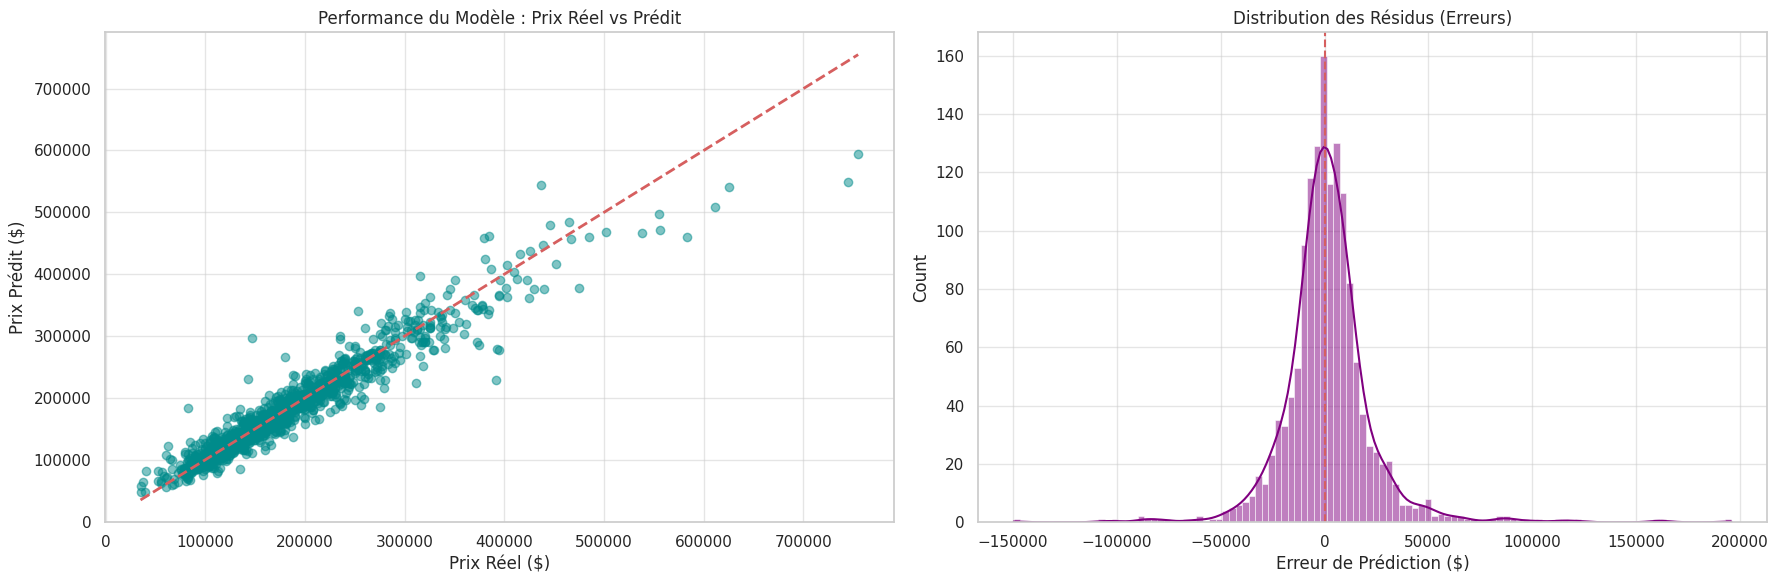


Déploiement réussi ! Le fichier 'M4.1_XGBoost.csv' est prêt pour Kaggle.


,Id,SalePrice
0,1461,129442.515625
1,1462,162970.453125
2,1463,185397.062500
3,1464,193581.687500
4,1465,184632.875000


In [39]:
# 1. Grille d'hyperparamètres (Élargie pour trouver un meilleur modèle)
param_grid = {
    'n_estimators': [1000, 2000],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.02, 0.05],
    'subsample': [0.7, 0.8],
    'colsample_bytree': [0.7, 0.8],
    'min_child_weight': [1, 2, 3]
}

xgb = XGBRegressor(random_state=42, objective='reg:squarederror')

# 2. Recherche du meilleur modèle (Cross-Validation)
print("Recherche des meilleurs hyperparamètres (GridSearch)...")
grid_search = GridSearchCV(estimator=xgb, param_grid=param_grid,
                           cv=5, scoring='neg_root_mean_squared_error',
                           n_jobs=-1, verbose=1)

grid_search.fit(X_train_selected, y_train)

best_xgb = grid_search.best_estimator_
best_score = -grid_search.best_score_

print(f"Meilleurs hyperparamètres : {grid_search.best_params_}")
print(f"RMSE de validation estimé : {best_score:.4f}")

# --- VALIDATION VISUELLE DU MODELE ---
# Générer des prédictions en cross-validation sur le jeu d'entraînement pour évaluer le modèle
print("\nGénération des graphiques d'évaluation...")
cv_preds_log = cross_val_predict(best_xgb, X_train_selected, y_train, cv=5)

# Inverser le log pour avoir les prix réels en dollars
y_train_real = np.expm1(y_train)
cv_preds_real = np.expm1(cv_preds_log)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Graphique 1 : Valeurs Réelles vs Prédictions
axes[0].scatter(y_train_real, cv_preds_real, alpha=0.5, color='darkcyan')
axes[0].plot([y_train_real.min(), y_train_real.max()], [y_train_real.min(), y_train_real.max()], 'r--', lw=2)
axes[0].set_xlabel('Prix Réel ($)')
axes[0].set_ylabel('Prix Prédit ($)')
axes[0].set_title('Performance du Modèle : Prix Réel vs Prédit')
# Formatage des axes en dollars pour plus de lisibilité
axes[0].ticklabel_format(style='plain', axis='both')

# Graphique 2 : Distribution des Résidus (Erreurs)
residuals = y_train_real - cv_preds_real
sns.histplot(residuals, kde=True, ax=axes[1], color='purple')
axes[1].axvline(x=0, color='r', linestyle='--')
axes[1].set_xlabel('Erreur de Prédiction ($)')
axes[1].set_title('Distribution des Résidus (Erreurs)')
axes[1].ticklabel_format(style='plain', axis='x')

plt.tight_layout()
plt.show()
# -------------------------------------

# 3. Prédictions finales pour Kaggle
log_preds = best_xgb.predict(X_test_selected)

# 4. Déploiement : Inversion du Log (expm1) et fichier Kaggle
final_preds = np.expm1(log_preds)

submission = pd.DataFrame({
    'Id': test_ids,
    'SalePrice': final_preds
})
submission.to_csv('M4.1_XGBoost.csv', index=False)

print("\nDéploiement réussi ! Le fichier 'M4.1_XGBoost.csv' est prêt pour Kaggle.")
submission.head()